In [17]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 缓存F1数据
# 替换原来这一行
fastf1.Cache.enable_cache("../cache")
# 加载一场比赛数据作为练习素材
session = fastf1.get_session(2025, "Bahrain", "R")
session.load()
laps = session.laps

print("数据加载成功！圈数据总量：", len(laps))


logger      WARNING 	Failed to load schedule from FastF1 backend!
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


ValueError: Failed to load any schedule data.

In [12]:
##Numpy核心基础
valid_laps = laps.dropna(subset=["LapTime"])# 筛选有效圈，剔除LapTime为空的行

lap_sec = valid_laps["LapTime"].dt.total_seconds().to_numpy()

first10 = lap_sec[:10]# 切片：前10圈速度
print(first10)
print(np.mean(lap_sec))#平均
print(np.min(lap_sec))#最快
print(np.max(lap_sec))#最慢

[98.693 97.492 98.083 98.133 98.043 98.363 98.498 98.567 98.8   98.549]
100.88746726457398
95.14
149.735


In [13]:
##Numpy广播+数组运算
avg=np.mean(lap_sec)
fast_laps=lap_sec[lap_sec<avg]#筛选出圈速高于平均值的圈次

best=np.min(lap_sec)
gap=lap_sec-best#计算每一圈和全场最快圈的差值


In [14]:
##pandas基础
# 查看表格基础信息
print(laps.head())
print(laps.columns)

ver_laps=laps[laps["Driver"]=='VER']# 单条件筛选：只看维斯塔潘全部圈速

simple_df = laps[["Driver", "LapNumber", "LapTime", "Compound"]]#提取指定列：车手、圈数、圈速、轮胎

                    Time Driver DriverNumber                LapTime  \
0 0 days 00:57:13.827000    PIA           81 0 days 00:01:38.693000   
1 0 days 00:58:51.319000    PIA           81 0 days 00:01:37.492000   
2 0 days 01:00:29.402000    PIA           81 0 days 00:01:38.083000   
3 0 days 01:02:07.535000    PIA           81 0 days 00:01:38.133000   
4 0 days 01:03:45.578000    PIA           81 0 days 00:01:38.043000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0        NaT       NaT                    NaT   
1        2.0    1.0        NaT       NaT 0 days 00:00:31.139000   
2        3.0    1.0        NaT       NaT 0 days 00:00:31.306000   
3        4.0    1.0        NaT       NaT 0 days 00:00:31.326000   
4        5.0    1.0        NaT       NaT 0 days 00:00:31.305000   

             Sector2Time  ... FreshTyre     Team           LapStartTime  \
0 0 days 00:00:42.130000  ...     False  McLaren 0 days 00:55:34.907000   
1 0 days 00:00:42.34

In [25]:
#pandas分组聚合
valid_laps["lap_sec"]=valid_laps["LapTime"].dt.total_seconds()#把时间转换为秒
#按车手分组，统计每位车手平均圈速、最快圈
group =valid_laps.groupby("Driver")["lap_sec"]
stat=group.agg(["mean","min"])
print(stat)

#按轮胎类型分组，对比不同轮胎平均圈速
tire_group=valid_laps.groupby("Compound")["lap_sec"].mean()
print(tire_group)

              mean     min
Driver                    
ALB     100.663357  97.141
ALO     100.858357  97.906
ANT     100.647446  96.690
BEA     101.526825  97.303
BOR     100.971571  98.006
DOO     101.618263  96.682
GAS     101.323456  96.531
HAD     101.679807  96.952
HAM     100.272036  96.235
HUL     101.629947  97.338
LAW     100.656357  97.380
LEC     100.018643  96.132
NOR      99.984000  95.728
OCO     101.468053  97.098
PIA      99.524375  95.140
RUS      99.948750  95.518
SAI     102.382955  96.954
STR     100.934000  98.064
TSU     100.589036  97.225
VER     101.295263  96.167
Compound
HARD      101.833248
MEDIUM    100.543125
SOFT      100.483722
Name: lap_sec, dtype: float64


C:\Users\陈词年\AppData\Local\Temp\ipykernel_11716\2156107132.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_laps["lap_sec"]=valid_laps["LapTime"].dt.total_seconds()#把时间转换为秒


In [20]:
#pandas数据清洗
clean_laps=laps.dropna(subset=["LapTime"])#删除空圈数据
clean_laps=clean_laps[clean_laps["PitInTime"].isna()]#过滤进站慢圈

clean_laps["lap_sec"]=clean_laps["LapTime"].dt.total_seconds()#时间统一转为秒数

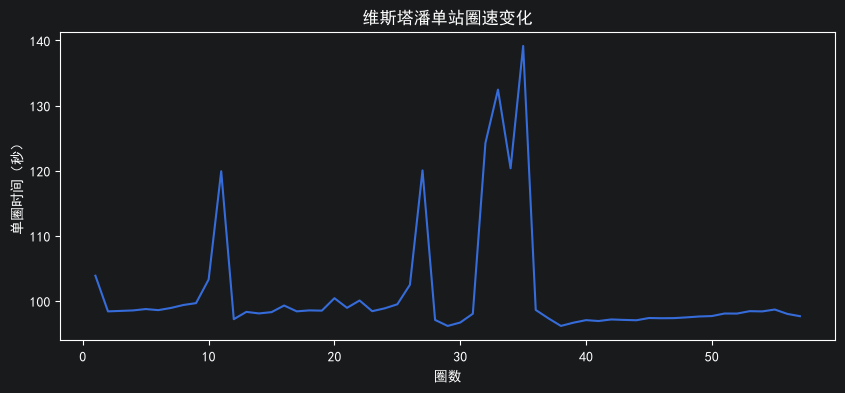

In [28]:
#matplotlib基础绘图
# ==========必须放在绘图代码最前面！解决中文方框乱码==========
plt.rcParams['font.sans-serif'] = ['SimHei']   # 黑体支持中文
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示异常
#绘制维斯塔潘全场圈速变化折线图
ver=laps[laps["Driver"]=="VER"]
plt.figure(figsize=(10,4))
plt.plot(ver["LapNumber"],ver["LapTime"].dt.total_seconds())
plt.title("维斯塔潘单站圈速变化")
plt.xlabel("圈数")
plt.ylabel("单圈时间（秒）")
plt.show()

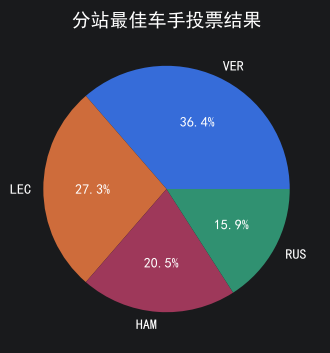

In [27]:
#matplotlib饼图+多子图
# ==========必须放在绘图代码最前面！解决中文方框乱码==========
plt.rcParams['font.sans-serif'] = ['SimHei']   # 黑体支持中文
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示异常
#模拟投票数据，绘制投票占比饼图
drivers=["VER","LEC","HAM","RUS"]
votes=[160,120,90,70]
plt.figure(figsize=(10,4))
plt.pie(votes,labels=drivers,autopct="%1.1f%%")
plt.title("分站最佳车手投票结果",fontsize=14)
plt.savefig("../vote_pie.png")
plt.show()